# Intermittent Demand with Hyper-Tree-TSB

Many real demand series are *intermittent*: most periods see zero demand, with occasional nonzero spikes (spare parts, slow-moving SKUs, new or end-of-life products). Autoregressive and exponential-smoothing target models are a poor fit here, because the series is the product of two separate processes rather than a smooth signal.

The **Teunter-Syntetos-Babai (TSB)** method models those two processes explicitly:

$$\hat{y}_{t+1} = p_t \cdot z_t$$

- a demand **probability** $p_t$, a smoothed occurrence indicator updated every period, and
- a demand **size** $z_t$, smoothed over the nonzero demands only.

The forecast for the next period is the product of the current states, the expected demand per period. `HyperTreeTSB` makes the two smoothing rates $\alpha_p$ and $\alpha_d$ time-varying functions of features, so the responsiveness of the probability and size estimates can adapt to drivers such as promotions or seasonality. This walkthrough simulates a panel of intermittent SKUs whose occurrence probability *and* size both depend on features, then compares the TSB Hyper-Tree against a univariate `HyperTreeAR` baseline.

In [1]:
import pandas as pd

from hypertrees import ForecastIntervals
from hypertrees.models import HyperTreeAR
from hypertrees.models.HyperTreeTSB import HyperTreeTSB
from utils import calculate_metrics, plot_panel_forecasts, simulate_intermittent_panel

# Shared setup
seed = 123
num_iterations = 200
level = [90]
forecast_intervals = ForecastIntervals(
    n_windows=8,                        # number of rolling calibration windows
    method="conformal_distribution",    # or "conformal_error"
    step_size=1,                        # time steps between windows
    refit=False,                        # train once on the oldest window for speed
)

## Simulate a Panel of Intermittent SKUs

We simulate 20 weekly SKUs over three years. Each SKU's demand is the product of two feature-driven components, which is exactly the structure TSB targets:

- the demand **probability** rises during promotions and follows a mild monthly seasonal cycle, and
- the demand **size** (units sold when demand occurs) is larger during promotions.

Both depend on a binary `promo` feature and on `month`, so a model whose smoothing rates are functions of features has real structure to exploit. The feature columns are `month`, `promo`, and a SKU identifier `series_num` (cast to pandas `category` dtype so LightGBM applies true categorical splits). All series share the same length, as TSB requires.

In [2]:
k, n_train, fcst_h = 20, 156, 12

df, train, test = simulate_intermittent_panel(k=k, n_train=n_train, fcst_h=fcst_h, seed=seed)

# A quick look at how intermittent the data is
zero_frac = (train["value"] == 0).mean()
print(f"{k} SKUs x {n_train} weeks, forecast horizon {fcst_h}")
print(f"Share of zero-demand weeks in training: {zero_frac:.0%}")
print(f"Mean weekly demand: {train['value'].mean():.2f}")

20 SKUs x 156 weeks, forecast horizon 12
Share of zero-demand weeks in training: 74%
Mean weekly demand: 1.47


## Hyper-Tree-TSB

The GBDT learns the two smoothing rates $\alpha_p$ (probability) and $\alpha_d$ (size) as functions of the features. The point forecast is flat over the horizon at the final state $p_T \cdot z_T$, the expected demand per period, which is the classical TSB forecast. We also calibrate a 90% conformal prediction interval via rolling-origin cross-validation.

In [3]:
tsb = HyperTreeTSB(
    freq="W",
    fcst_h=fcst_h,
)
tsb.train(
    lgb_params={"learning_rate": 0.1},
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    forecast_intervals=forecast_intervals,
)
tsb_fcst = tsb.forecast(test_data=test, level=level)

## Univariate Baseline: Hyper-Tree-AR

An autoregressive target model cannot represent the "occurrence times size" structure of intermittent demand. On a mostly-zero series its lags are usually zero, and because a pure AR model has no intercept its forecasts collapse toward zero and miss the underlying demand rate. We give it the same features and forecast horizon for a fair comparison.

In [4]:
ar = HyperTreeAR(
    p=8,
    freq="W",
    fcst_h=fcst_h,
)
ar.train(
    lgb_params={"learning_rate": 0.1},
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    forecast_intervals=forecast_intervals,
)
ar_fcst = ar.forecast(test_data=test, level=level)

## Forecasts

Three of the twenty SKUs, with the 90% conformal interval of the `Hyper-Tree-TSB`. TSB settles on each SKU's expected demand rate and carries it across the horizon, while the AR forecast decays toward zero.

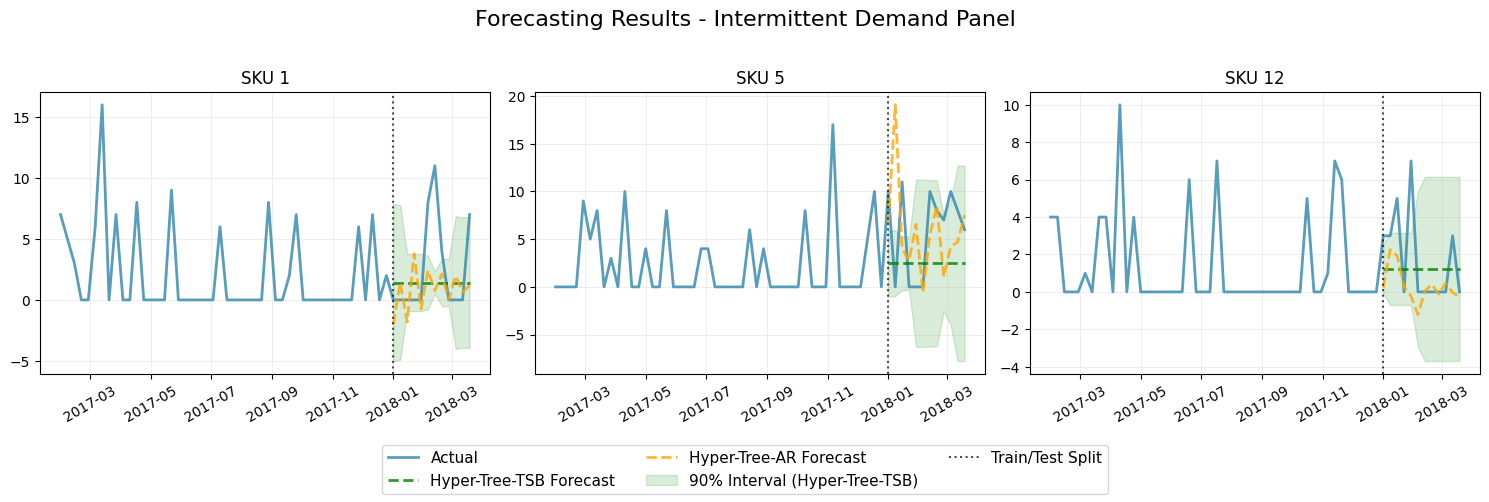

In [5]:
datasets = [
    (df, "date", "value", "Actual", "#2E86AB", "-"),
    (tsb_fcst, "date", "fcst", "Hyper-Tree-TSB Forecast", "green", "--"),
    (ar_fcst, "date", "fcst", "Hyper-Tree-AR Forecast", "orange", "--"),
]

plot_panel_forecasts(
    datasets,
    series_ids=["SKU 1", "SKU 5", "SKU 12"],
    split_date=test["date"].min(),
    interval_fcst=tsb_fcst,
    level=level[0],
    history=60,
    title="Forecasting Results - Intermittent Demand Panel",
)

### Why the TSB forecast is flat

The flat line is not a limitation of the fit but the defining behaviour of the whole Croston family (Croston, SBA, TSB): these methods are *demand-rate estimators*, not trajectory models. Their states only change when new observations arrive, and beyond the forecast origin there are none, so the estimated rate $p_T \cdot z_T$ propagates unchanged. The question they answer is "how many units per period should I expect from now on", which is exactly what inventory control (their original purpose) consumes for reorder points and safety stocks. In `HyperTreeTSB` the features modulate the smoothing *rates*, so they shape how the states track the history, but they cannot move the point forecast over the horizon.

A non-flat profile would require a channel for known future information such as promotion calendars or seasonality, which the Croston family does not have. Models with that channel include hurdle or zero-inflated regressions that map features directly to the occurrence probability and demand size, or temporal aggregation approaches (ADIDA/MAPA) that forecast at a smoother aggregate level and disaggregate back. So when reading the plot above: the wiggle in the AR line is mostly noise-chasing on a mostly-zero series, while the flat TSB line is the calibrated demand rate.

## Inspecting the Time-Varying Smoothing Rates

`forecast(type="parameters")` returns the learned smoothing rates `alpha_p` (probability) and `alpha_d` (size) for every row. Because they are functions of the features, they are not constant the way a classical TSB fit would be. Below we average each rate by `promo` state across the test panel, which shows the model smoothing differently in promotional versus baseline weeks.

In [10]:
params = tsb.forecast(test_data=test, type="parameters")
params = params.merge(test[["series_id", "date", "promo"]], on=["series_id", "date"])

# The learned smoothing rates are not constant: they shift with the promo flag.
params.head(20)

,series_id,date,model,alpha_p,alpha_d,promo
0,SKU 1,2018-01-01,Hyper-Tree-TSB,0.216877,0.587008,0
1,SKU 1,2018-01-08,Hyper-Tree-TSB,0.216877,0.587008,0
2,SKU 1,2018-01-15,Hyper-Tree-TSB,0.216877,0.587008,0
3,SKU 1,2018-01-22,Hyper-Tree-TSB,0.216877,0.587008,0
4,SKU 1,2018-01-29,Hyper-Tree-TSB,0.216877,0.587008,0
5,SKU 1,2018-02-05,Hyper-Tree-TSB,0.019815,0.405759,0
6,SKU 1,2018-02-12,Hyper-Tree-TSB,0.026231,0.322118,1
7,SKU 1,2018-02-19,Hyper-Tree-TSB,0.026231,0.322118,1
8,SKU 1,2018-02-26,Hyper-Tree-TSB,0.019815,0.405759,0
9,SKU 1,2018-03-05,Hyper-Tree-TSB,0.038430,0.096568,0


## Accuracy Comparison

Point-forecast metrics need care on intermittent data. The flat TSB forecast estimates the *expected* demand per period, and squared error (RMSE) is minimized by exactly that conditional mean, so RMSE is the fairest yardstick here. The absolute metrics (MAE, WAPE) are minimized by forecasting close to zero on mostly-zero series, so they reward degenerate forecasts and can exceed 100% WAPE even for a well-calibrated demand rate. MAPE is undefined on zero-demand weeks and is computed only on the nonzero subset. The TSB model estimates each SKU's expected demand rate, while the AR baseline, lacking an intercept, decays toward zero on the mostly-zero history and underforecasts.

In [7]:
fcsts_df = pd.concat(
    [
        tsb_fcst,
        ar_fcst,
    ], axis=0).merge(
    test[["series_id", "date", "value"]],
    on=["series_id", "date"],
    how="inner"
)

fcsts_df.groupby("model")[["value", "fcst"]].apply(calculate_metrics).round(3)

,MAE,MAPE,sMAPE,WAPE,RMSE
model,,,,,
Hyper-Tree-AR(8),2.573,76.377,156.345,129.468,4.012
Hyper-Tree-TSB,2.331,71.810,170.232,117.276,3.219


## Practical Notes

- **Equal-length panel**: TSB reshapes the panel to (n_series, T), so all series must have the same length. Pad shorter series and supply a `mask` column (1 = valid, 0 = padding); padded rows are excluded from the loss and from the conformity scores.
- **Flat point forecast**: the TSB forecast is constant over the horizon at `p_T * z_T`. Horizon features therefore do not move the point forecast, though they do change `type="parameters"`. This is the classical TSB behaviour: future occurrence is unobserved, so the expected one-step-ahead state propagates unchanged.
- **Feature-driven smoothing**: the gain over classical TSB comes from letting `alpha_p` and `alpha_d` vary with features, so the probability and size estimates adapt their responsiveness by context (promotions, season, SKU).
- **When to use it**: reach for TSB when the series is genuinely intermittent. On smooth, non-zero series an AR or ETS target model is usually the better fit.